In [2]:
cluster_number = 9 
seed_name = 'YP_522685.1_thiopurine_S-methyltransferase'

#'''{'Cluster_0': ['ANH82019.1'], 'Cluster_1': ['Burkholderia_xenovorans_YP_557005'], 'Cluster_2': ['Neosartorya_fischeri_XP_001266691'], 'Cluster_3': ['YP_432621.1_SAM-dependent_methyltransferase'], 'Cluster_4': ['Algoriphagus_sp._ZP_01720187'], 'Cluster_5': ['ZP_00987534.1_COG0500_SAM-dependent_methyltransferases'], 'Cluster_6': ['Anaeromyxobacter_dehalogenans_YP_466408'], 'Cluster_7': ['Polaribacter_irgensii_ZP_01117536'], 'Cluster_8': ['3LCC_A'], 'Cluster_9': ['YP_522685.1_thiopurine_S-methyltransferase']}'''

# Imports

In [3]:
# import packages
import os, sys, glob
import numpy as np
import pandas as pd
import multiprocessing as mp
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import argparse

from functools import partial
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sys.path.append('../')

In [4]:
# Check if the variables exist, otherwise set default values
if 'cluster_number' not in globals():
    cluster_number = None # Default value if not set externally

if 'seed_name' not in globals():
    seed_name = None  # Default value if not set externally

#cluster_number = 0 0 0
#seed_name = "ANH82019.1" "ANH82019.1" 'ANH82019.1'
print(f"Running notebook with Cluster: {cluster_number}, Seed Name: {seed_name}")

Running notebook with Cluster: 9, Seed Name: YP_522685.1_thiopurine_S-methyltransferase


# Preprocessing

In [5]:
# load data such that each row is a sample with one column for name and one for sequence
# add sequence 'names as a ft
def load_data(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        seqs = []
        names = []
        for i in range(0, len(lines)):
            # split line by tab
            line = lines[i].split('\t')
            names.append(line[0][1:].strip())
            seqs.append(line[1].strip())
    return pd.DataFrame({'name': names,
                         'sequence': seqs})
# Big clustering
#seqs = load_data('../data/Final_Sequences_PlusRefSeq20.clustalo.Output.oneline.Residue_Columns_With_2Nbrs.txt')
#Sub-clustering
cluster_data_path = f"/Users/3et/ilenne/clustering/subclustering/Cluster_{cluster_number}/Results/"  
seqs = load_data(cluster_data_path + f"{seed_name}.Final.txt")
seqs.head()
print(len(seqs))
print(seqs)

398
                                           name  \
0                                    ABD69154.1   
1                                    ALT75848.1   
2                                  CAA0125624.1   
3                                  CAG1018993.1   
4                                    HCY64078.1   
..                                          ...   
393                              WP_375186366.1   
394                              WP_377159745.1   
395                              WP_382250601.1   
396                                  WVH09995.1   
397  YP_522685.1_thiopurine_S-methyltransferase   

                                              sequence  
0    EFWQEQERFEETGWDTGWDREQTCLCLCAILCAIHLFMQMQGPPYG...  
1    EFWKEKERFAQTAWDTAWDREQTCLCLCALLCALHLFMQAEGPPYG...  
2    DYWHSHSHWVEIRFHIRFHQDRAAIAIVALIVALPTAAVYQKPPFK...  
3    SFWQQQQRFENVPWDVPWDREQTCLCLCALLCALHLFMQVEGPPYG...  
4    DFWQTQTRFENTPWDTPWDREQTCLCLCALLCALHLFVQSKGPPYG...  
..                                       

In [6]:
#NOTE: We should not have negative counts - need to clean this up
# read in counts file
'''with open('../data/Final_Sequences_PlusRefSeq20.clustalo.Output.oneline.Residue_Columns_With_2Nbrs.Non_Gap_Depth.txt', 'r') as f:
    lines = f.readlines()
    counts = lines[0].split('\t')

counts = [count.strip() for count in counts][1:]
counts_prop = [1 - (int(count) / 8466) for count in counts]
sorted(counts_prop)[:5]
print(len(seqs))'''

"with open('../data/Final_Sequences_PlusRefSeq20.clustalo.Output.oneline.Residue_Columns_With_2Nbrs.Non_Gap_Depth.txt', 'r') as f:\n    lines = f.readlines()\n    counts = lines[0].split('\t')\n\ncounts = [count.strip() for count in counts][1:]\ncounts_prop = [1 - (int(count) / 8466) for count in counts]\nsorted(counts_prop)[:5]\nprint(len(seqs))"

In [7]:
# get sequences of interest
names_of_interest = ["Batis_maritima_AAD26120",
                     "Batis_maritima_AAD26120_point_mutation_V4N",
                     "Batis_maritima_AAD26120_point_mutation_C23V",
                     "Anaeromyxobacter_dehalogenans_YP_466408",
                     "Brassica_oleracea_2_AAK69761",
                     "Phaeosphaeria_nodorum_XP_001792029",
                     "Ralstonia_solanacearum_NP_518583",
                     "Vitis_vinifera_2_CAO46361",
                     "Polaribacter_irgensii_ZP_01117536",
                     "Burkholderia_xenovorans_YP_557005",
                     "Algoriphagus_sp._ZP_01720187",
                     "Neosartorya_fischeri_XP_001266691",
                     "YP_432621.1_SAM-dependent_methyltransferase",
                     "XP_001272206.1_thiol_methyltransferase_putative",
                     "EAY92545.1_hypothetical_protein_OsI_14284",
                     "XP_762636.1_hypothetical_protein_UM06489.1",
                     "ZP_00987534.1_COG0500_SAM-dependent_methyltransferases",
                     "YP_522685.1_thiopurine_S-methyltransferase",
                     "YP_557005.1_hypothetical_protein_Bxe_A4046",
                     "AAK69761.1_thiol_methyltransferase_2", 
                     f"{seed_name}"]

In [8]:
# check if names of interest are in the data
names_in_data = [name for name in names_of_interest if name in seqs['name'].values]
for name in names_of_interest:
    if name not in seqs['name'].values:
        print(f'{name} not found in data')
    else:
        print("Name:", name)
        print("Sequence:", seqs[seqs['name'] == name]['sequence'].values[0])
        print()

Batis_maritima_AAD26120 not found in data
Batis_maritima_AAD26120_point_mutation_V4N not found in data
Batis_maritima_AAD26120_point_mutation_C23V not found in data
Anaeromyxobacter_dehalogenans_YP_466408 not found in data
Brassica_oleracea_2_AAK69761 not found in data
Phaeosphaeria_nodorum_XP_001792029 not found in data
Ralstonia_solanacearum_NP_518583 not found in data
Vitis_vinifera_2_CAO46361 not found in data
Polaribacter_irgensii_ZP_01117536 not found in data
Burkholderia_xenovorans_YP_557005 not found in data
Algoriphagus_sp._ZP_01720187 not found in data
Neosartorya_fischeri_XP_001266691 not found in data
YP_432621.1_SAM-dependent_methyltransferase not found in data
XP_001272206.1_thiol_methyltransferase_putative not found in data
EAY92545.1_hypothetical_protein_OsI_14284 not found in data
XP_762636.1_hypothetical_protein_UM06489.1 not found in data
ZP_00987534.1_COG0500_SAM-dependent_methyltransferases not found in data
Name: YP_522685.1_thiopurine_S-methyltransferase
Sequence

In [9]:
# check sequence lengths
seq_len = np.unique(seqs['sequence'].apply(len))[0]
seq_len

60

In [10]:
# Save sequences names that were removed due to 'X' in a file
seqs_with_X = seqs[seqs['sequence'].str.contains('X')]
seqs_with_X.to_csv(f"../data/subcluster/cluster_{cluster_number}_sequences_with_X.csv", index=False)

# if any sequence contains 'X', drop them + the name
# NOTE: REPLACE SEQUENCES WITH 'X' WITH '-'

seqs = seqs[~seqs['sequence'].str.contains('X')]

# reset index to 0-8461
seqs = seqs.reset_index(drop=True) 

# get list of unique amino acids
amino_acids = [aa for aa in set(''.join(seqs['sequence']))]
amino_acids.sort()
len(amino_acids), len(seqs)

(21, 398)

In [11]:
# SCORES / FEATURES are subject to change
# create a dictionary mapping amino acids to specific features
# first, define features we want to include

# 1. hydrophobicity (ordinal)
hydrophobic = ['A', 'C', 'I', 'L', 'M', 'F', 'V', 'W'] # 0
neutral = ['G', 'H', 'P', 'S', 'T', 'Y'] # 1
hydrophilic = ['R', 'N', 'D', 'Q', 'E', 'K', '-'] # 2

hydrophobicity = {2: hydrophobic, 
                  1: neutral, 
                  0: hydrophilic}

# 2. volume (ordinal)
very_small = ['A', 'G', 'S'] #0
small = ['N', 'D', 'C', 'P', 'T'] #1
medium = ['Q', 'E', 'H', 'V'] #2
large = ['R', 'I', 'L', 'K', 'M'] #3
very_large = ['F', 'W', 'Y'] #4
na = ['-']

volume = {1: very_small, 
          2: small, 
          3: medium, 
          4: large, 
          5: very_large,
          0: na}

# 3. chemical (arbitrary)
aliphatic = ['A', 'G', 'I', 'L', 'P', 'V']
aromatic = ['F', 'W', 'Y']
sulfur = ['C', 'M']
hydroxyl = ['S', 'T']
basic = ['R', 'H', 'K']
acidic = ['D', 'E']
amide = ['N', 'Q']
na = ['-']

# one-hot encode
chemical = {'aliphatic': aliphatic,
            'aromatic': aromatic,
            'sulfur': sulfur,
            'hydroxyl': hydroxyl,
            'basic': basic,
            'acidic': acidic,
            'amide': amide,
            'na': na}

onehot_chemical = {'aliphatic': [1, 0, 0, 0, 0, 0, 0, 0], 
            'aromatic': [0, 1, 0, 0, 0, 0, 0, 0], 
            'sulfur': [0, 0, 1, 0, 0, 0, 0, 0], 
            'hydroxyl': [0, 0, 0, 1, 0, 0, 0, 0], 
            'basic': [0, 0, 0, 0, 1, 0, 0, 0], 
            'acidic': [0, 0, 0, 0, 0, 1, 0, 0], 
            'amide': [0, 0, 0, 0, 0, 0, 1, 0],
            'na': [0, 0, 0, 0, 0, 0, 0, 1]}

# 4. charge (ordinal)
positive = ['R', 'H', 'K'] #1
negative = ['D', 'E'] #-1
uncharged = ['A', 'N', 'C', 'Q', 'G', 'I', 'L', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V', '-'] #0

charge = {1: positive, 
          int(-1): negative, 
          0: uncharged}

# 5. hydrogen donor/acceptor (arbitrary)
# MAYBE CHANGE TO BINARY (BOND/NOT)
bond = ['R', 'K', 'W', 'D', 'E', 'N', 'Q', 'H', 'S', 'T', 'Y']
none = ['A', 'C', 'G', 'I', 'L', 'M', 'F', 'P', 'V', '-']

hydrogen = {1: bond,
            0: none}

# 6. polarity (ordinal)
polar = ['R', 'N', 'D', 'Q', 'E', 'H', 'K', 'S', 'T', 'Y'] #1
nonpolar = ['A', 'C', 'G', 'I', 'L', 'M', 'F', 'P', 'W', 'V'] #0
na = ['-']

polarity = {'polar': polar, 
            'nonpolar': nonpolar,
            'gap': na}

onehot_polarity = {'polar': [1, 0, 0],
                    'nonpolar': [0, 1, 0],
                    'gap': [0, 0, 1]}

protonAffinity = {0.09:['A'], 0.1:['C'], 0.18:['D'], 0.33:['E', 'N'], 0.24:['F'], 0:['G', '-'], 0.57:['H'], 0.22:['I', 'T'], 0.51:['K'], 0.2:['L'], 0.28:['M'], \
                  0.35:['P'], 0.46:['Q'], 1:['R'], 0.16:['S'], 0.19:['V'], 0.37:['W'], 0.26:['Y']}

globalChemSoft = {0.09:['A', 'L'], 0.29:['C'], 0:['D', '-'], 0.13:['E', 'P'], 0.59:['F'], 0.08:['G', 'N', 'T'], 0.55:['H'], 0.05:['I', 'S'], 0.17:['K'], 0.43:['M'], \
                  0.12:['Q'], 0.45:['R'], 0.04:['V'], 1:['W'], 0.75:['Y']}
bkbnChemSoft = {0.89:['A'], 0.18:['C'], 0.64:['D'], 0.78:['E'], 0.06:['F'], 1:['G'], 0:['H', '-'], 0.8:['I'], 0.37:['K'], 0.79:['L'], 0.32:['M'], 0.53:['N'], 0.76:['P', 'T'], \
                0.65:['Q'], 0.39:['R'], 0.85:['S'], 0.81:['V'], 0.02:['W'], 0.05:['Y']}
sdcnChemSoft = {0.08:['A'], 0.66:['C'], 0.24:['D'], 0.17:['E', 'T'], 0.84:['F'], 0:['G', '-'], 0.87:['H'], 0.14:['I'], 0.49:['K'], 0.15:['L'], 0.6:['M'], 0.34:['N'], 0.2:['P'], \
                0.26:['Q'], 0.56:['R'], 0.1:['S'], 0.12:['V'], 1:['W'], 0.91:['Y']}
globalPolarizability = {0.11:['A'], 0.28:['C'], 0.26:['D'], 0.36:['E'], 0.71:['F'], 0:['G', '-'], 0.51:['H'], 0.45:['I', 'L'], 0.53:['K'], 0.5:['M'], 0.3:['N'], 0.29:['P'], \
                        0.41:['Q'], 0.67:['R'], 0.14:['S'], 0.25:['T'], 0.34:['V'], 1:['W'], 0.76:['Y']}
bkbnPolarizability = {0.89:['A'], 0.76:['C'], 0.57:['D', 'F', 'Q'], 0.65:['E'], 1:['G'], 0.46:['H'], 0.55:['I'], 0.7:['K'], 0.67:['L'], 0.77:['M', 'S'], 0.56:['N'], 0:['P', '-'], \
                    0.52:['R'], 0.53:['T', 'W'], 0.54:['V'], 0.58:['Y']}
sdcnPolarizability = {0.1:['A'], 0.26:['C'], 0.23:['D'], 0.35:['E'], 0.68:['F'], 0:['G', '-'], 0.47:['H', 'K'], 0.42:['I'], 0.43:['L'], 0.5:['M'], 0.27:['N'], 0.3:['P'], \
                      0.38:['Q'], 0.61:['R'], 0.12:['S'], 0.24:['T'], 0.32:['V'], 1:['W'], 0.73:['Y']}


# allows us to map amino acids to features, creating a (num_samples, seq_length, num_features) tensor
feature_list = [\
    hydrophobicity, \
    volume, \
    chemical, \
    charge, \
    hydrogen, \
    #polarity, \
    protonAffinity, \
    globalChemSoft, \
    #bkbnChemSoft, \
    sdcnChemSoft, \
    globalPolarizability, \
    bkbnPolarizability, \
    #sdcnPolarizability \
]

In [12]:
# create feature dictionary that contains the properties of each amino acid
feature_dict = {}

# loop through each amino acid and create a dictionary of features
# loop through amino acids
for aa in amino_acids:
    
    # make list of features for each amino acid
    features = []
    
    # loop through each feature
    for feature in feature_list:

        # loop through each key in the feature dictionary
        for key, list in feature.items():
            if key in onehot_chemical.keys():
                if aa in list:
                    features.extend(onehot_chemical[key])
                continue
            elif key in onehot_polarity.keys():
                if aa in list:
                    features.extend(onehot_polarity[key])
                continue
            if aa in list:
                features.append(key)
    feature_dict[aa] = features

# print dictionary for feature conversion
feature_dict

{'-': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 'A': [2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.09, 0.09, 0.08, 0.11, 0.89],
 'C': [2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.29, 0.66, 0.28, 0.76],
 'D': [0, 2, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.18, 0, 0.24, 0.26, 0.57],
 'E': [0, 3, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.33, 0.13, 0.17, 0.36, 0.65],
 'F': [2, 5, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0.24, 0.59, 0.84, 0.71, 0.57],
 'G': [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0, 0, 1],
 'H': [1, 3, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.57, 0.55, 0.87, 0.51, 0.46],
 'I': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.22, 0.05, 0.14, 0.45, 0.55],
 'K': [0, 4, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.51, 0.17, 0.49, 0.53, 0.7],
 'L': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.09, 0.15, 0.45, 0.67],
 'M': [2, 4, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.28, 0.43, 0.6, 0.5, 0.77],
 'N': [0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0.33, 0.08, 0.34, 0.3, 0.56],
 'P': [1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0.13, 0.2, 0.29, 0],
 '

In [13]:
num_fts = len(feature_dict["-"])
num_fts

17

In [14]:
# Load data from file ../data/Disorder_Matrix_WithZeros_noX.tsv
def load_disorder_data(filepath):
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
            seqs_disorder = []
            names = []
            for i in range(0, len(lines)):
                # split line by tab
                line = lines[i].split('\t')
                names.append(line[0].strip())
                seqs_disorder.append([float(x.strip()) for x in line[1:]])
        return pd.DataFrame({'name': names,
                             'sequence_disorder': seqs_disorder})
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return pd.DataFrame({'name': [], 'sequence_disorder': []})

#seqs_disorder = load_disorder_data('../data/Disorder_Matrix_WithZeros_noX.tsv')
#sub-clustering
seqs_disorder = load_disorder_data(cluster_data_path + f"{seed_name}.Disorder.tsv")
seqs_disorder.head()


,name,sequence_disorder
0,ABD69154.1,"[0.124, 0.077, 0.062, 0.096, 0.116, 0.096, 0.1..."
1,ALT75848.1,"[0.108, 0.072, 0.06, 0.092, 0.105, 0.092, 0.10..."
2,CAA0125624.1,"[0.046, 0.025, 0.02, 0.036, 0.044, 0.036, 0.04..."
3,CAG1018993.1,"[0.172, 0.11, 0.095, 0.137, 0.148, 0.137, 0.14..."
4,HCY64078.1,"[0.185, 0.126, 0.111, 0.147, 0.14, 0.147, 0.14..."


In [15]:
feature_dict

{'-': [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
 'A': [2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.09, 0.09, 0.08, 0.11, 0.89],
 'C': [2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.29, 0.66, 0.28, 0.76],
 'D': [0, 2, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.18, 0, 0.24, 0.26, 0.57],
 'E': [0, 3, 0, 0, 0, 0, 0, 1, 0, 0, -1, 1, 0.33, 0.13, 0.17, 0.36, 0.65],
 'F': [2, 5, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0.24, 0.59, 0.84, 0.71, 0.57],
 'G': [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0, 0, 1],
 'H': [1, 3, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.57, 0.55, 0.87, 0.51, 0.46],
 'I': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.22, 0.05, 0.14, 0.45, 0.55],
 'K': [0, 4, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0.51, 0.17, 0.49, 0.53, 0.7],
 'L': [2, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.09, 0.15, 0.45, 0.67],
 'M': [2, 4, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0.28, 0.43, 0.6, 0.5, 0.77],
 'N': [0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0.33, 0.08, 0.34, 0.3, 0.56],
 'P': [1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0.13, 0.2, 0.29, 0],
 '

In [16]:
# convert sequences to feature tensors
def seq_to_tensor(seq, feature_dict):
    # initialize tensor
    tensor = []
    
    # loop through each amino acid in the sequence
    for aa in seq:
        # get features for amino acid
        features = feature_dict[aa]
        tensor.append(features)
        
    return np.array(tensor)

In [17]:
# Print the dimensions of the tensor
seq = seqs['sequence'][0]
tensor = seq_to_tensor(seq, feature_dict)
print(tensor.shape)


(60, 17)


In [18]:
seq_tensors = []
for seq, disorder_vector in zip(seqs['sequence'], seqs_disorder['sequence_disorder']):
    feature_tensor = []
    for i, aa in enumerate(seq):
        feature_tensor.append(feature_dict[aa] + [disorder_vector[i]])
    seq_tensors.append(feature_tensor)

# print the tensors for the first 5 sequences in a file
with open('../data/subcluster/seq_tensors_check.txt', 'w') as f:
    for i in range(5):
        f.write(f'{seq_tensors[i]}\n')

In [19]:
# Update num_fts to include disorder
num_fts = len(feature_dict["-"]) + 1
num_fts



18

In [20]:
# get names
names = seqs['name']
print(len(names))

398


In [21]:
# get index of names of interest
soi_idx = [i for i in names.index if names[i] in names_of_interest]

In [22]:
for name in names_in_data:
    if name not in names.values:
        print(f'{name} not found in data')

In [23]:
# convert list of tensors to numpy array
seq_tensors = np.array(seq_tensors)
seq_tensors = seq_tensors.reshape(-1, seq_len*num_fts) # num residues x num fts per residue
seq_tensors.shape

(398, 1080)

In [24]:
# scale data
seq_tensors_norm = normalize(seq_tensors)

# Dimension Reduction
* Reducing dimensions to 2 for easy visualization

In [25]:
# perform pca
pca = PCA(n_components=2)
pca_result = pca.fit_transform(seq_tensors_norm)

# perform tsne
tsne = TSNE(n_components=2, verbose=1, perplexity=40)
tsne_results = tsne.fit_transform(seq_tensors_norm)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 398 samples in 0.001s...
[t-SNE] Computed neighbors for 398 samples in 0.064s...
[t-SNE] Computed conditional probabilities for sample 398 / 398
[t-SNE] Mean sigma: 0.121579
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.545452
[t-SNE] KL divergence after 1000 iterations: 0.449208


In [26]:
# get soi pca + tsne results
soi_pca = pca_result[soi_idx, :]
soi_tsne = tsne_results[soi_idx, :]

soi_pca.shape, soi_tsne.shape

((1, 2), (1, 2))

# K-Means Clustering

In [27]:
# specify num_clusters with controller variable
num_clusters = 12

# perform kmeans clustering
K = range(2, num_clusters)
fits = []
scores = []

for k in K:
    # fit k clusters on data
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(seq_tensors_norm)
    fits.append(kmeans)

    # get silhouette score
    silhouette = silhouette_score(seq_tensors_norm, kmeans.labels_, metric='euclidean')
    scores.append(silhouette)
    print(f'k={k}, score={silhouette}')

print(f"Best silhouette score: {min(scores)}, for k={scores.index(min(scores))+2}")
best_kmeans = fits[scores.index(min(scores))]
print(best_kmeans)
best_kmeans_k = scores.index(min(scores))+2
print(best_kmeans_k)
# Write the best silhouete score to a fine without overwriting
with open(f"../data/subcluster/kmeanse_best_silhouette_scores.txt", 'a') as f:
    f.write(f"Cluster_{cluster_number}   Best silhouette score: {min(scores)}, for k={scores.index(min(scores))+2}\n")

k=2, score=0.09865398138810265
k=3, score=0.1147993287371265
k=4, score=0.11662451623612599
k=5, score=0.13948998648737246
k=6, score=0.15199797536141893
k=7, score=0.16878520429401392
k=8, score=0.1701675785957526
k=9, score=0.1420590742949403
k=10, score=0.18939574706467358
k=11, score=0.17558278782247333
Best silhouette score: 0.09865398138810265, for k=2
KMeans(n_clusters=2, n_init=10, random_state=0)
2


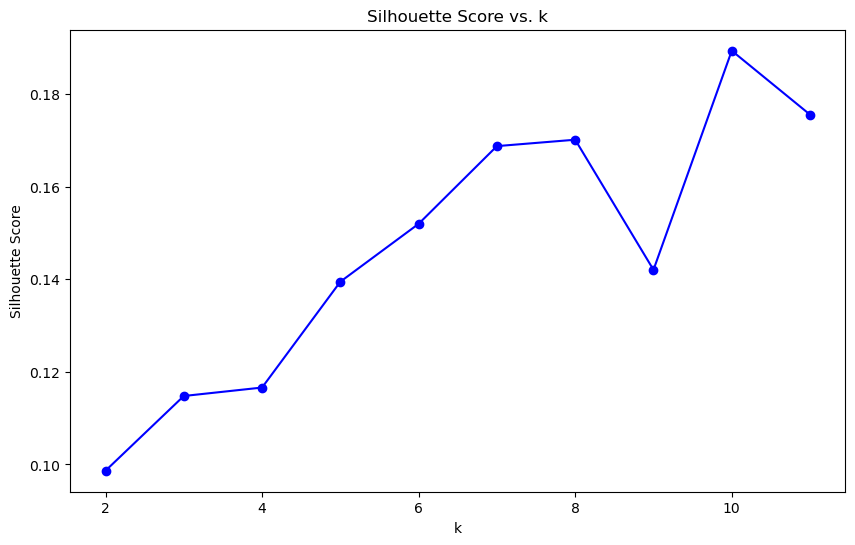

In [28]:
# plot scores vs. k
plt.figure(figsize=(10, 6))
plt.plot(K, scores, 'bo-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k')
# Save plot as a file
plt.savefig(f"../data/subcluster/subclustering_{cluster_number}_silhouette_score_vs_k.png", bbox_inches='tight')
plt.show()




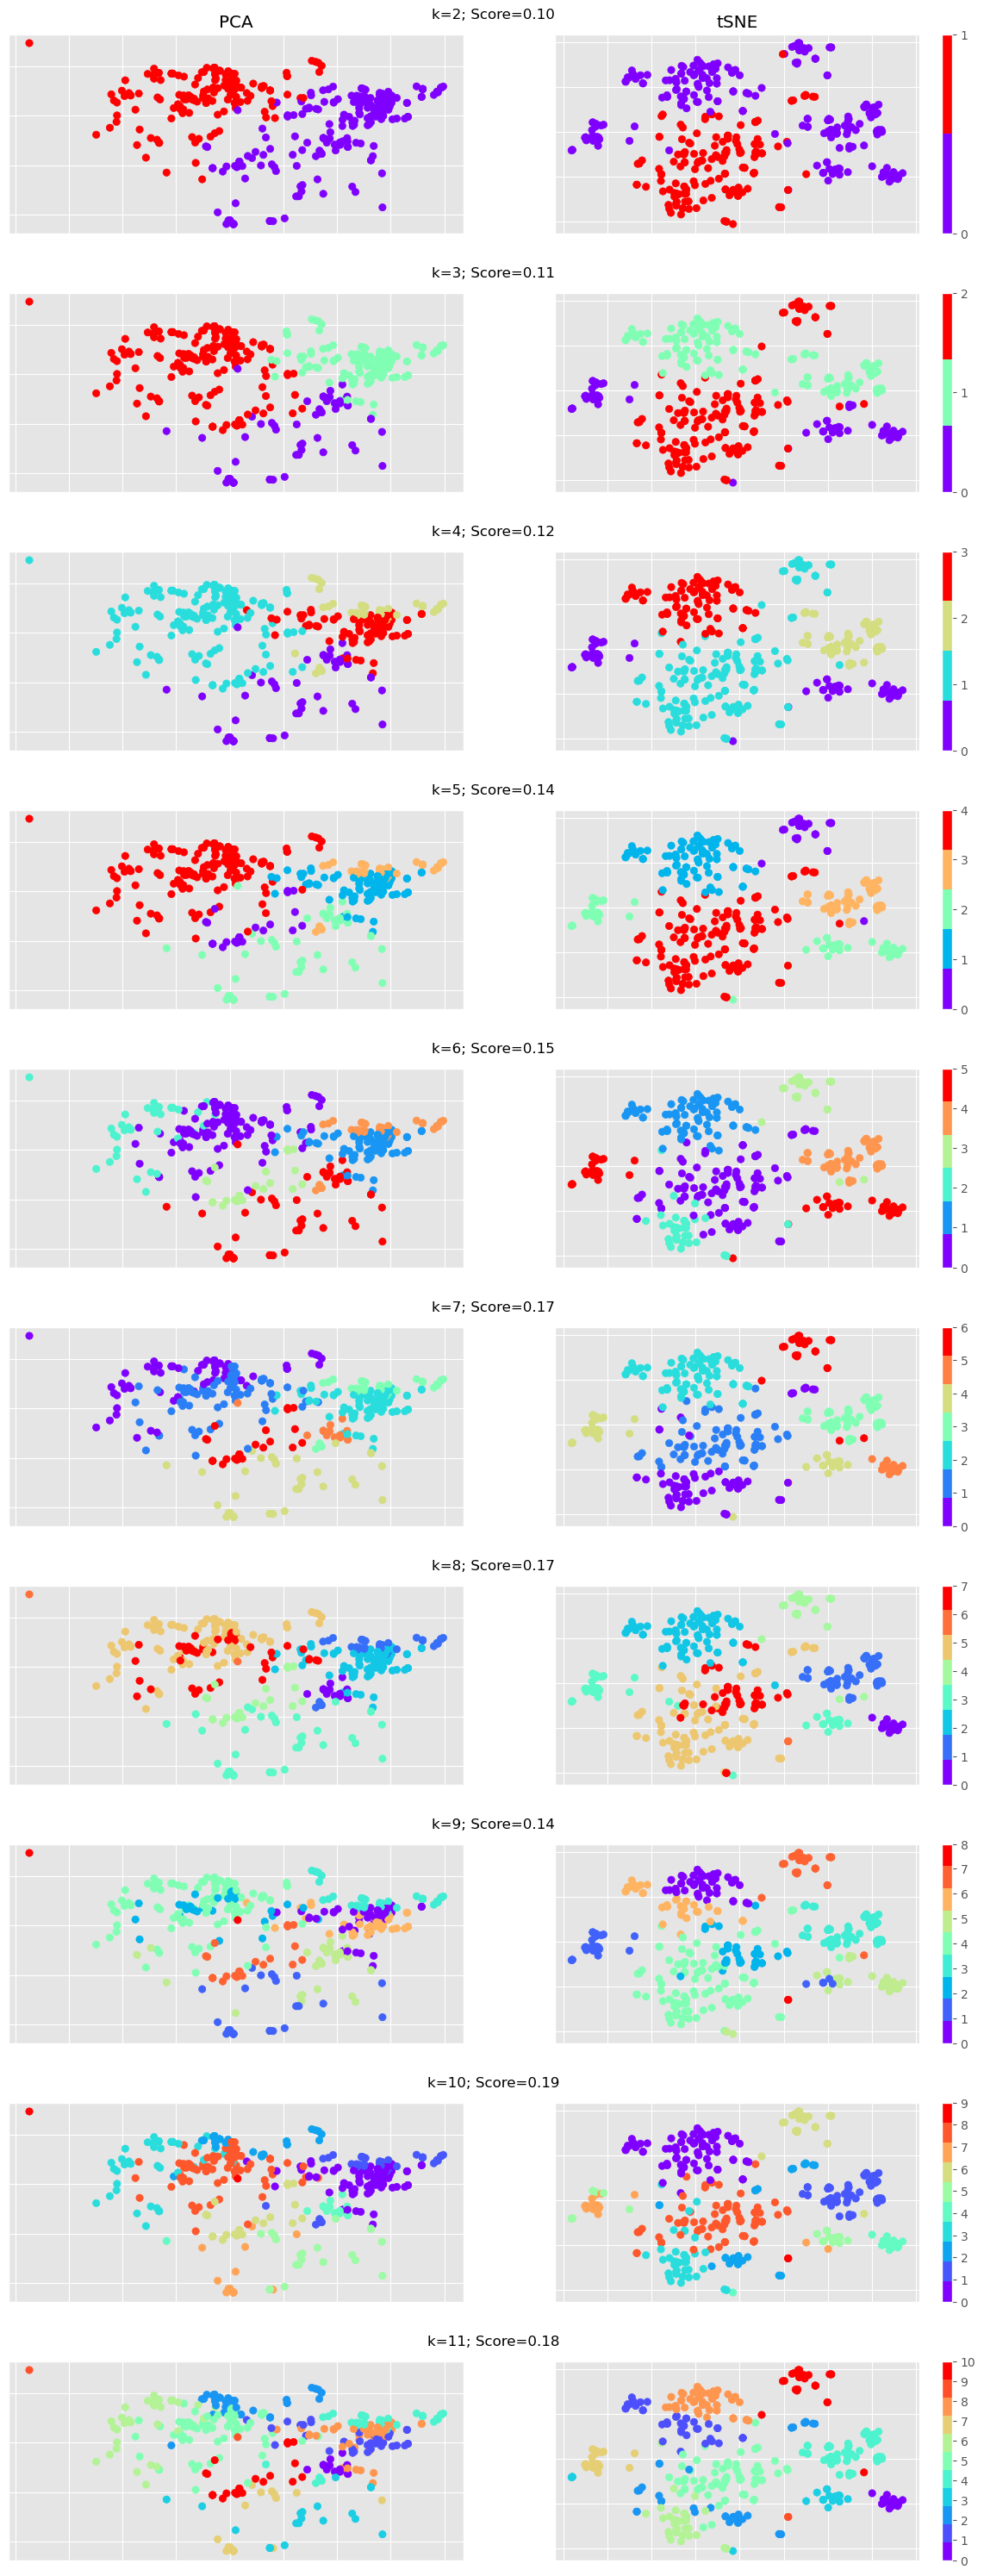

In [29]:
# plot clusters with tsne
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(15, 30))

    # create subplots
    subfigs = fig.subfigures(len(fits), 1)

    for row, subfig in enumerate(subfigs):
        cmap = plt.get_cmap('rainbow', len(np.unique(fits[row].labels_)))

        # get classes
        classes = fits[row].labels_
        score = scores[row]

        subfig.suptitle(f'k={row+2}; Score={score:.2f}')

        ax = subfig.subplots(nrows=1, ncols=2)
        # plot pca
        ax[0].scatter(pca_result[:,0], pca_result[:,1], c=classes, cmap=cmap)


        # plot tsne
        subfig.colorbar(ax[1].scatter(tsne_results[:,0], tsne_results[:,1], c=classes, cmap=cmap),
                        ticks = range(0, row+2),  
                        format = '%1i')
        if row == 0:
            ax[0].set_title('PCA')
            ax[1].set_title('tSNE')

        ax[0].tick_params(left = False, right = False , labelleft = False , 
                          labelbottom = False, bottom = False)
        ax[1].tick_params(left = False, right = False , labelleft = False , 
                          labelbottom = False, bottom = False) 
    plt.show()


# Hierarchical Clustering
* Using standard [agglomerative clustering](../notes/ClusteringMethods.md) methods.

In [30]:
# perform hierarchical clustering
# number of clusters to  try
N = range(2, num_clusters)
agg_fits = []
agg_scores = []
for n in N:
    agg_fit = AgglomerativeClustering(n_clusters=n, linkage='ward').fit_predict(seq_tensors_norm)
    agg_fits.append(agg_fit)

    agg_score = silhouette_score(seq_tensors_norm, agg_fit)
    agg_scores.append(agg_score)
    print(f'Clusters = {n}, Score = {agg_score}')
print(f"Best silhouette score: {min(agg_scores)}, for k={agg_scores.index(min(agg_scores))+2}")
best_agg = agg_fits[agg_scores.index(min(agg_scores))]
# Write the best silhouete score to a file without overwriting
with open(f"../data/subcluster/hc_best_silhouette_scores.txt", 'a') as f:
    f.write(f"Cluster_{cluster_number}   Best silhouette score: {min(agg_scores)}, for k={agg_scores.index(min(agg_scores))+2}\n")

Clusters = 2, Score = 0.09421687195522292
Clusters = 3, Score = 0.11605080758258218
Clusters = 4, Score = 0.11244968184415058
Clusters = 5, Score = 0.12973766692955613
Clusters = 6, Score = 0.13843711794995947
Clusters = 7, Score = 0.14968815655330384
Clusters = 8, Score = 0.16729064914421837
Clusters = 9, Score = 0.1762606205135608
Clusters = 10, Score = 0.1833609549109865
Clusters = 11, Score = 0.181957638684601
Best silhouette score: 0.09421687195522292, for k=2


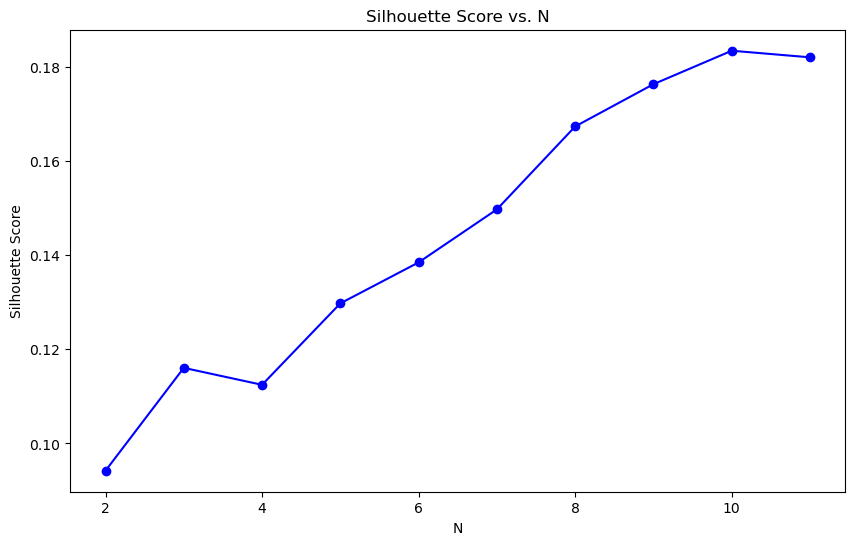

In [31]:
# plot scores vs. k
plt.figure(figsize=(10, 6))
plt.plot(N, agg_scores, 'bo-')
plt.xlabel('N')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. N')
plt.savefig(f"../data/subcluster/subclustering_{cluster_number}_silhouete_score_vs_k_hc.png", bbox_inches='tight')
plt.show()

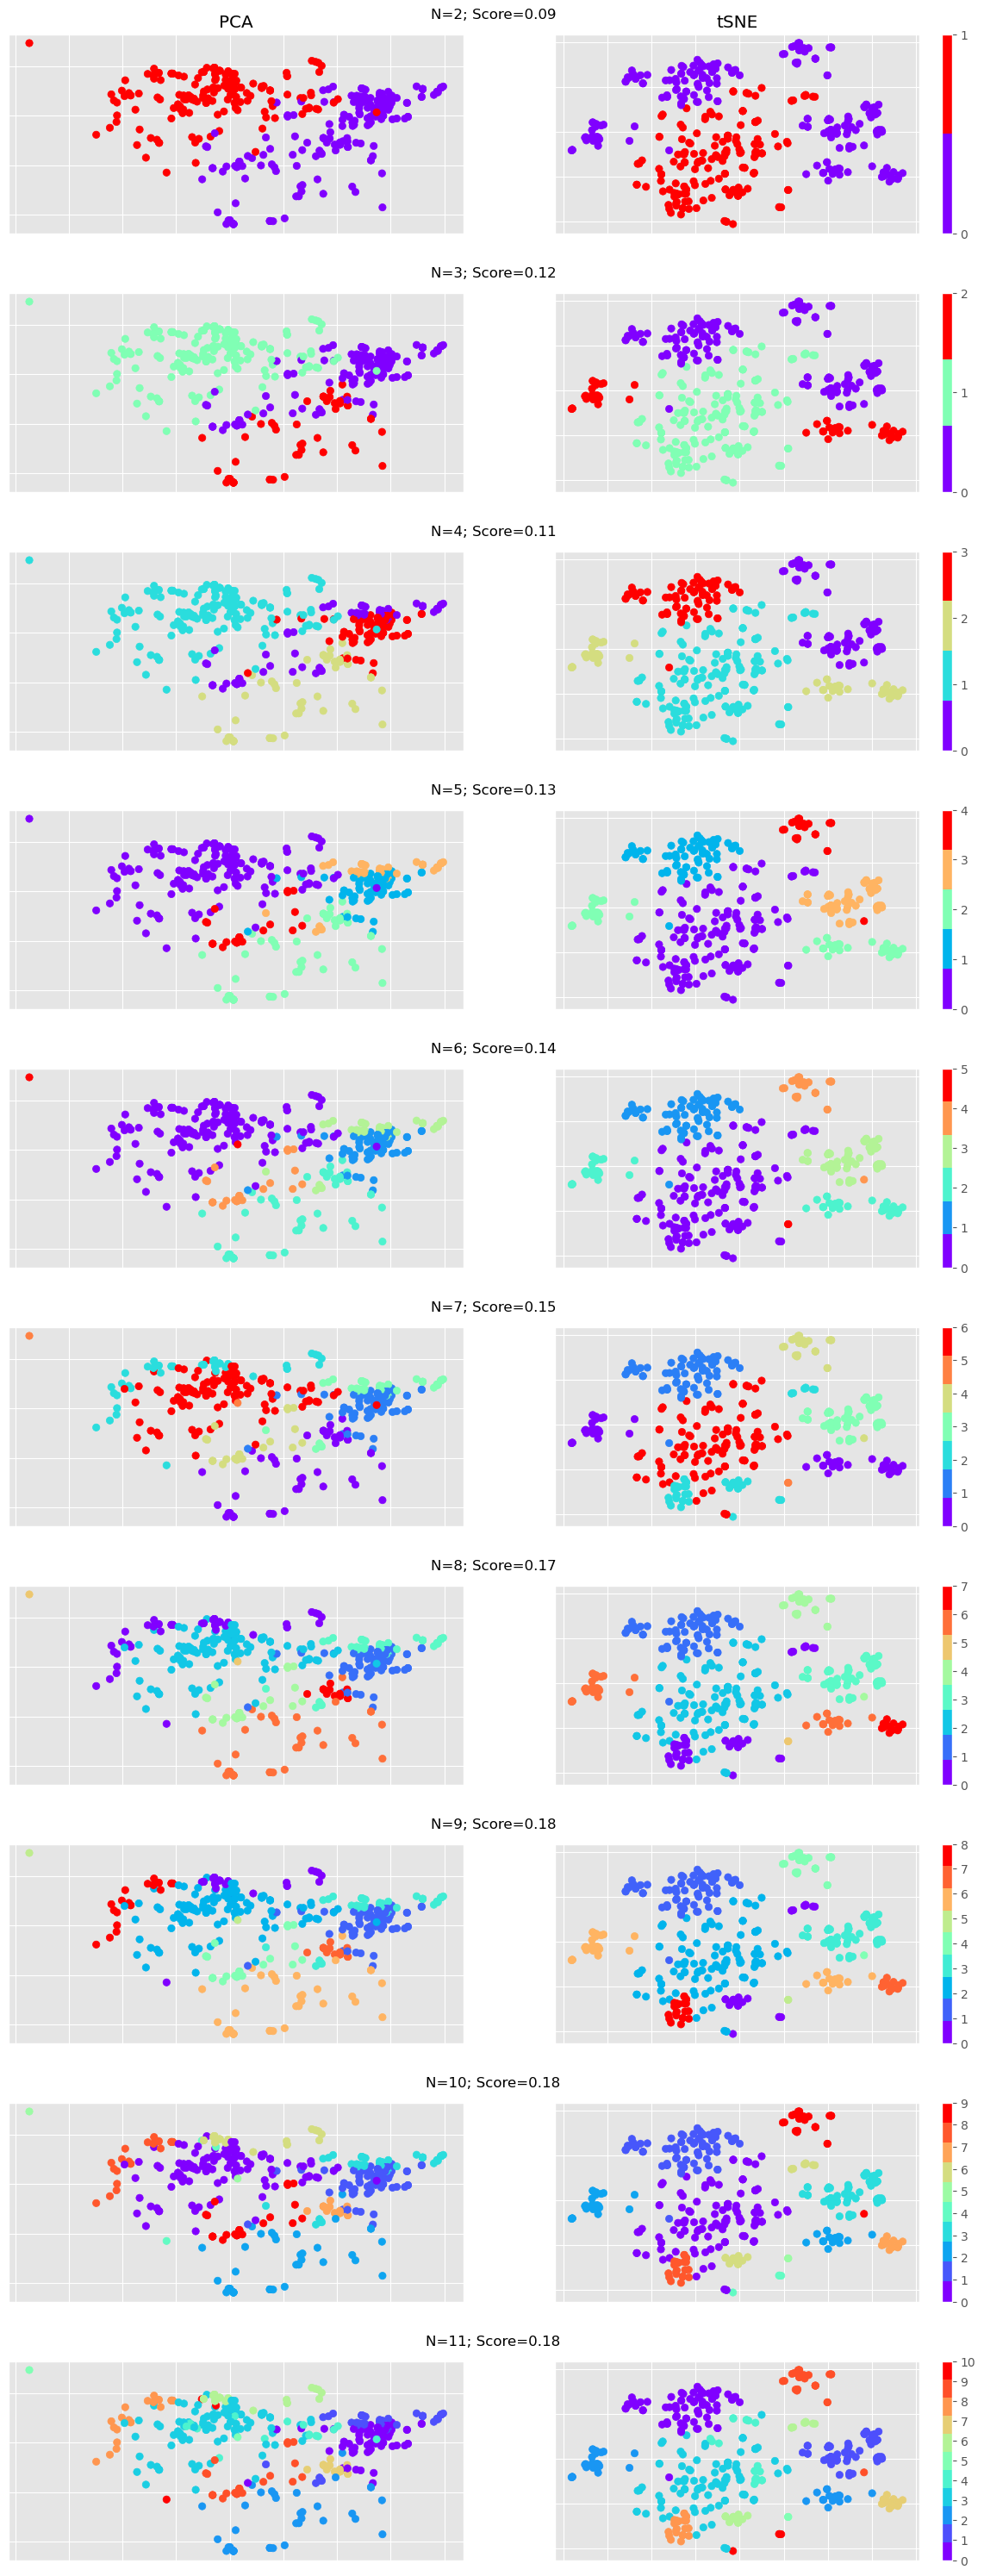

In [32]:
# plot hc clusters with tsne / pca
# plot clusters with tsne
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(15, 30))

    # create subplots
    subfigs = fig.subfigures(len(fits), 1)

    for row, subfig in enumerate(subfigs):
        cmap = plt.get_cmap('rainbow', len(np.unique(fits[row].labels_)))

        # get classes
        classes = agg_fits[row]
        score = agg_scores[row]

        subfig.suptitle(f'N={row+2}; Score={score:.2f}')

        ax = subfig.subplots(nrows=1, ncols=2)
        # plot pca
        ax[0].scatter(pca_result[:,0], pca_result[:,1], c=classes, cmap=cmap)

        # plot tsne
        subfig.colorbar(ax[1].scatter(tsne_results[:,0], tsne_results[:,1], c=classes, cmap=cmap),
                        ticks = range(0, row+2),  
                        format = '%1i')
        if row == 0:
            ax[0].set_title('PCA')
            ax[1].set_title('tSNE')

        ax[0].tick_params(left = False, right = False , labelleft = False , 
                          labelbottom = False, bottom = False)
        ax[1].tick_params(left = False, right = False , labelleft = False , 
                          labelbottom = False, bottom = False)

    plt.show()

# Plot K-Means and Hierarchical Clusters Side-by-Side

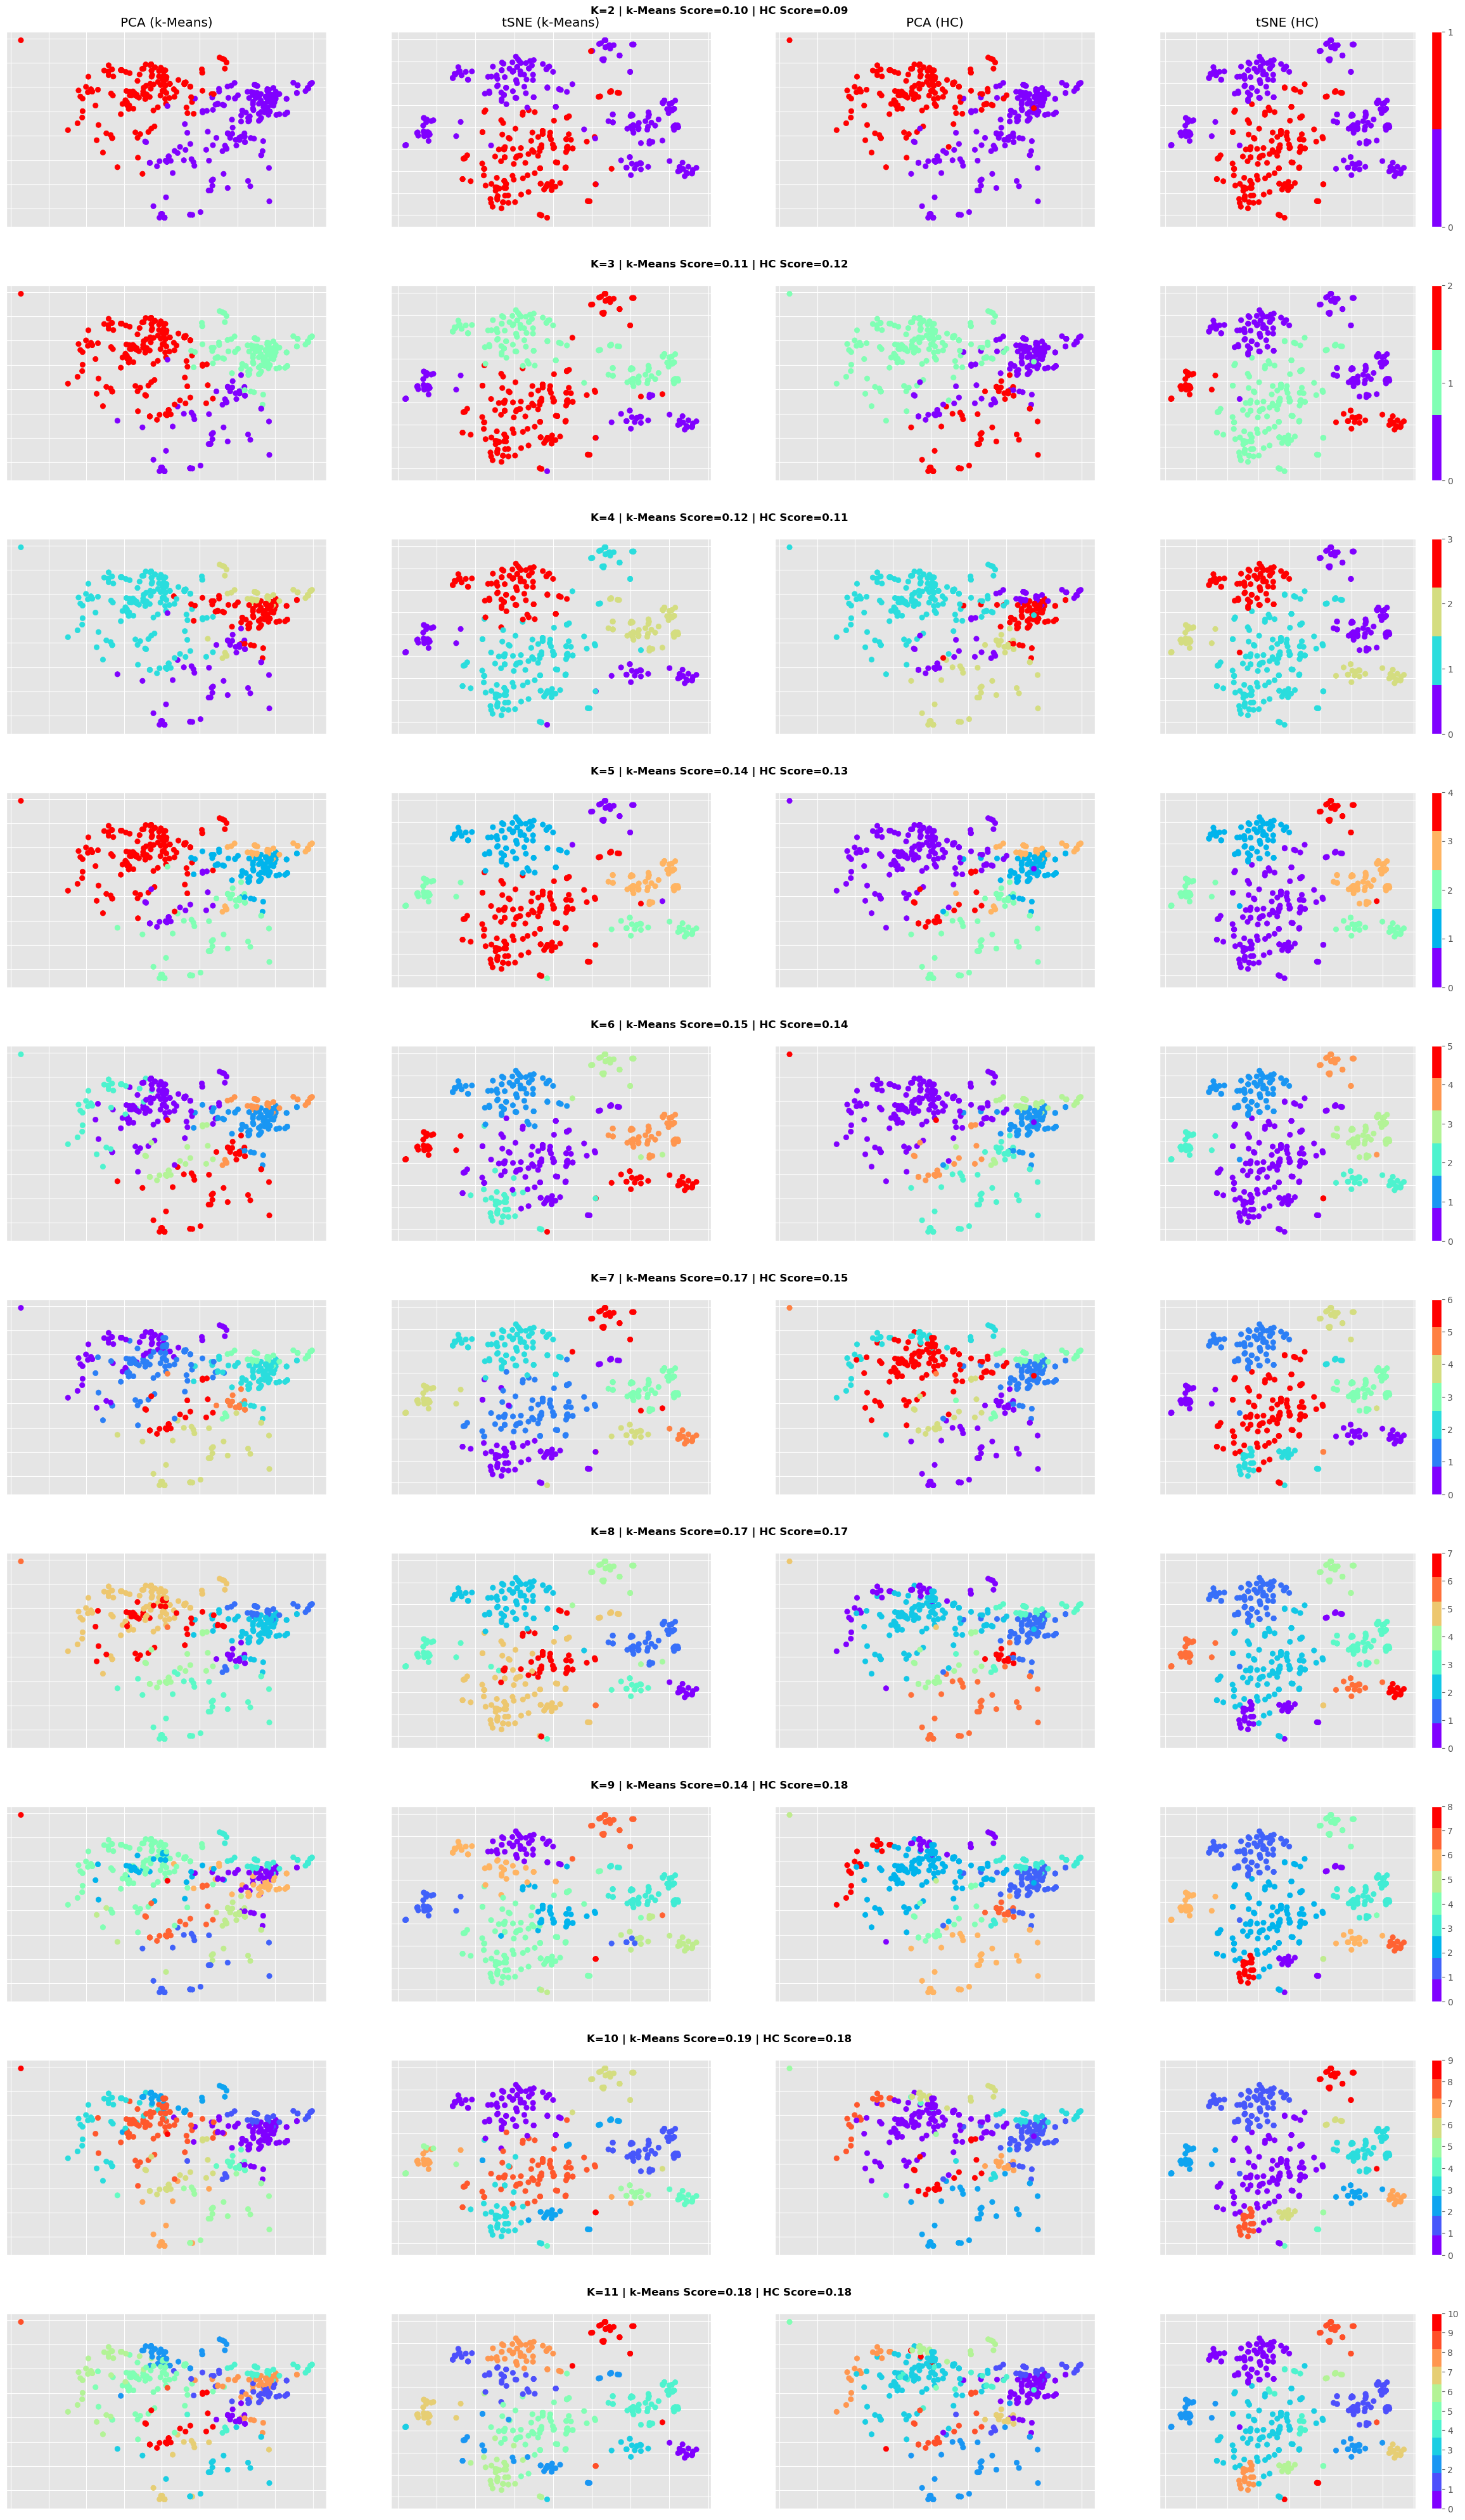

In [33]:
# plot hc and kmeans clusters side by side
# plot hc clusters with tsne / pca
# plot clusters with tsne
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(30, 40))

    # create subplots
    subfigs = fig.subfigures(len(fits), 1)

    for row, subfig in enumerate(subfigs):
        cmap = plt.get_cmap('rainbow', len(np.unique(fits[row].labels_)))
        # get kmeans classes
        kmeans_classes = fits[row].labels_
        kmeans_score = scores[row]

        # get hc classes
        agg_classes = agg_fits[row]
        agg_score = agg_scores[row]

        subfig.suptitle(f'K={row+2} | k-Means Score={kmeans_score:.2f} | HC Score={agg_score:.2f}', weight='bold')

        ax = subfig.subplots(nrows=1, ncols=4)

        # plot pca (all points)
        ax[0].scatter(pca_result[:,0], pca_result[:,1], c=kmeans_classes, cmap=cmap)
        ax[2].scatter(pca_result[:,0], pca_result[:,1], c=agg_classes, cmap=cmap)

        # plot tsne
        ax[1].scatter(tsne_results[:,0], tsne_results[:,1], c=kmeans_classes, cmap=cmap)
        
        subfig.colorbar(ax[3].scatter(tsne_results[:,0], tsne_results[:,1], c=agg_classes, cmap=cmap),
                        ticks = range(0, row+2),  
                        format = '%1i')

        if row == 0:
            ax[0].set_title('PCA (k-Means)')
            ax[1].set_title('tSNE (k-Means)')
            ax[2].set_title('PCA (HC)')
            ax[3].set_title('tSNE (HC)')

        for i in range(4):
            ax[i].tick_params(left = False, right = False , labelleft = False , 
                            labelbottom = False, bottom = False)
        
    plt.show()


# Highlight Sequences of Interest in Clusters

In [34]:
# define random jitter function to separate identical points
def rand_jitter(arr):
    stdev = .01 * (max(arr) - min(arr))
    return arr + np.random.randn(len(arr)) * stdev

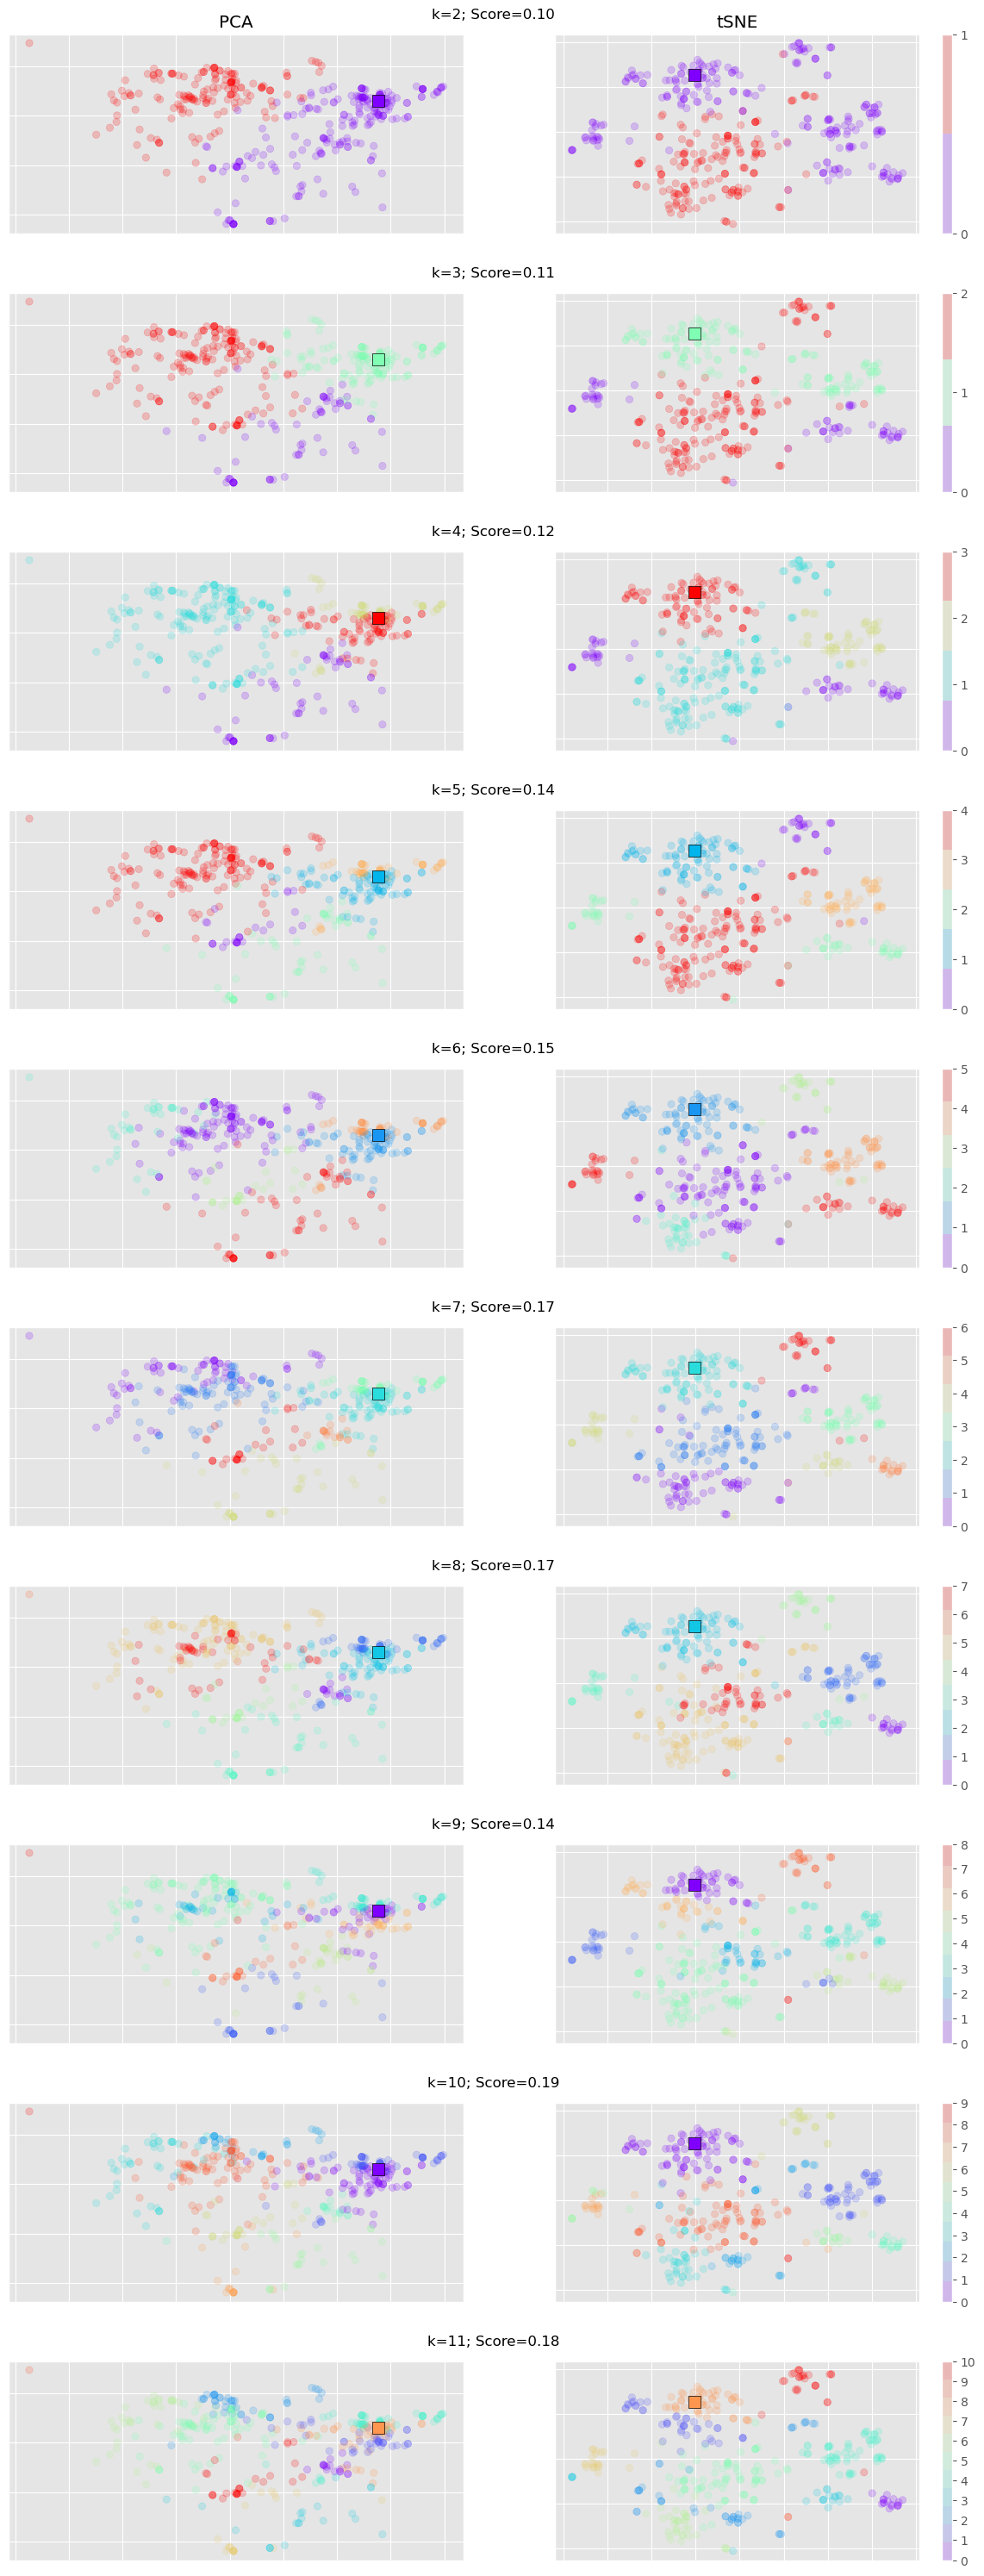

In [35]:
# plot clusters with tsne
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(15, 30))

    # create subplots
    subfigs = fig.subfigures(len(fits), 1)
    
    for row, subfig in enumerate(subfigs):
        cmap = plt.get_cmap('rainbow', len(np.unique(fits[row].labels_)))

        # get classes
        classes = fits[row].labels_
        clist = {i: cmap(i) for i in range(len(np.unique(classes)))}
        score = scores[row]
    
            
        # get labels and index for each sequence of interest
        soi_classes = [classes[i] for i in soi_idx]
        

        subfig.suptitle(f'k={row+2}; Score={score:.2f}')
        # create subplot only for best k
        #subfig.suptitle(f'k={best_kmeans_k}; Score={score:.2f}') 
        ax = subfig.subplots(nrows=1, ncols=2)

        # plot pca (all clusters)
        ax[0].scatter(pca_result[:,0], pca_result[:,1], c=classes, cmap=cmap, alpha=0.2)
        ax[0].scatter(rand_jitter(soi_pca[:,0]),rand_jitter(soi_pca[:,1]), marker=",", c=[clist[i] for i in soi_classes], edgecolor='black', s=100)

        # plot tsne
        subfig.colorbar(ax[1].scatter(tsne_results[:,0], tsne_results[:,1], c=classes, cmap=cmap, alpha=0.2),
                        ticks = range(0, row+2),  
                        format = '%1i')

        ax[1].scatter(rand_jitter(soi_tsne[:,0]),rand_jitter(soi_tsne[:,1]), marker=",", c=[clist[i] for i in soi_classes], edgecolor='black', s=100)

        if row == 0:
            ax[0].set_title('PCA')
            ax[1].set_title('tSNE')

        ax[0].tick_params(left = False, right = False , labelleft = False , 
                          labelbottom = False, bottom = False)
        ax[1].tick_params(left = False, right = False , labelleft = False , 
                          labelbottom = False, bottom = False) 
    # Save plot as a file
    plt.savefig(f"../data/subcluster/subclustering_{cluster_number}_kmeans_pca_tsne.png", bbox_inches='tight')
    plt.show()



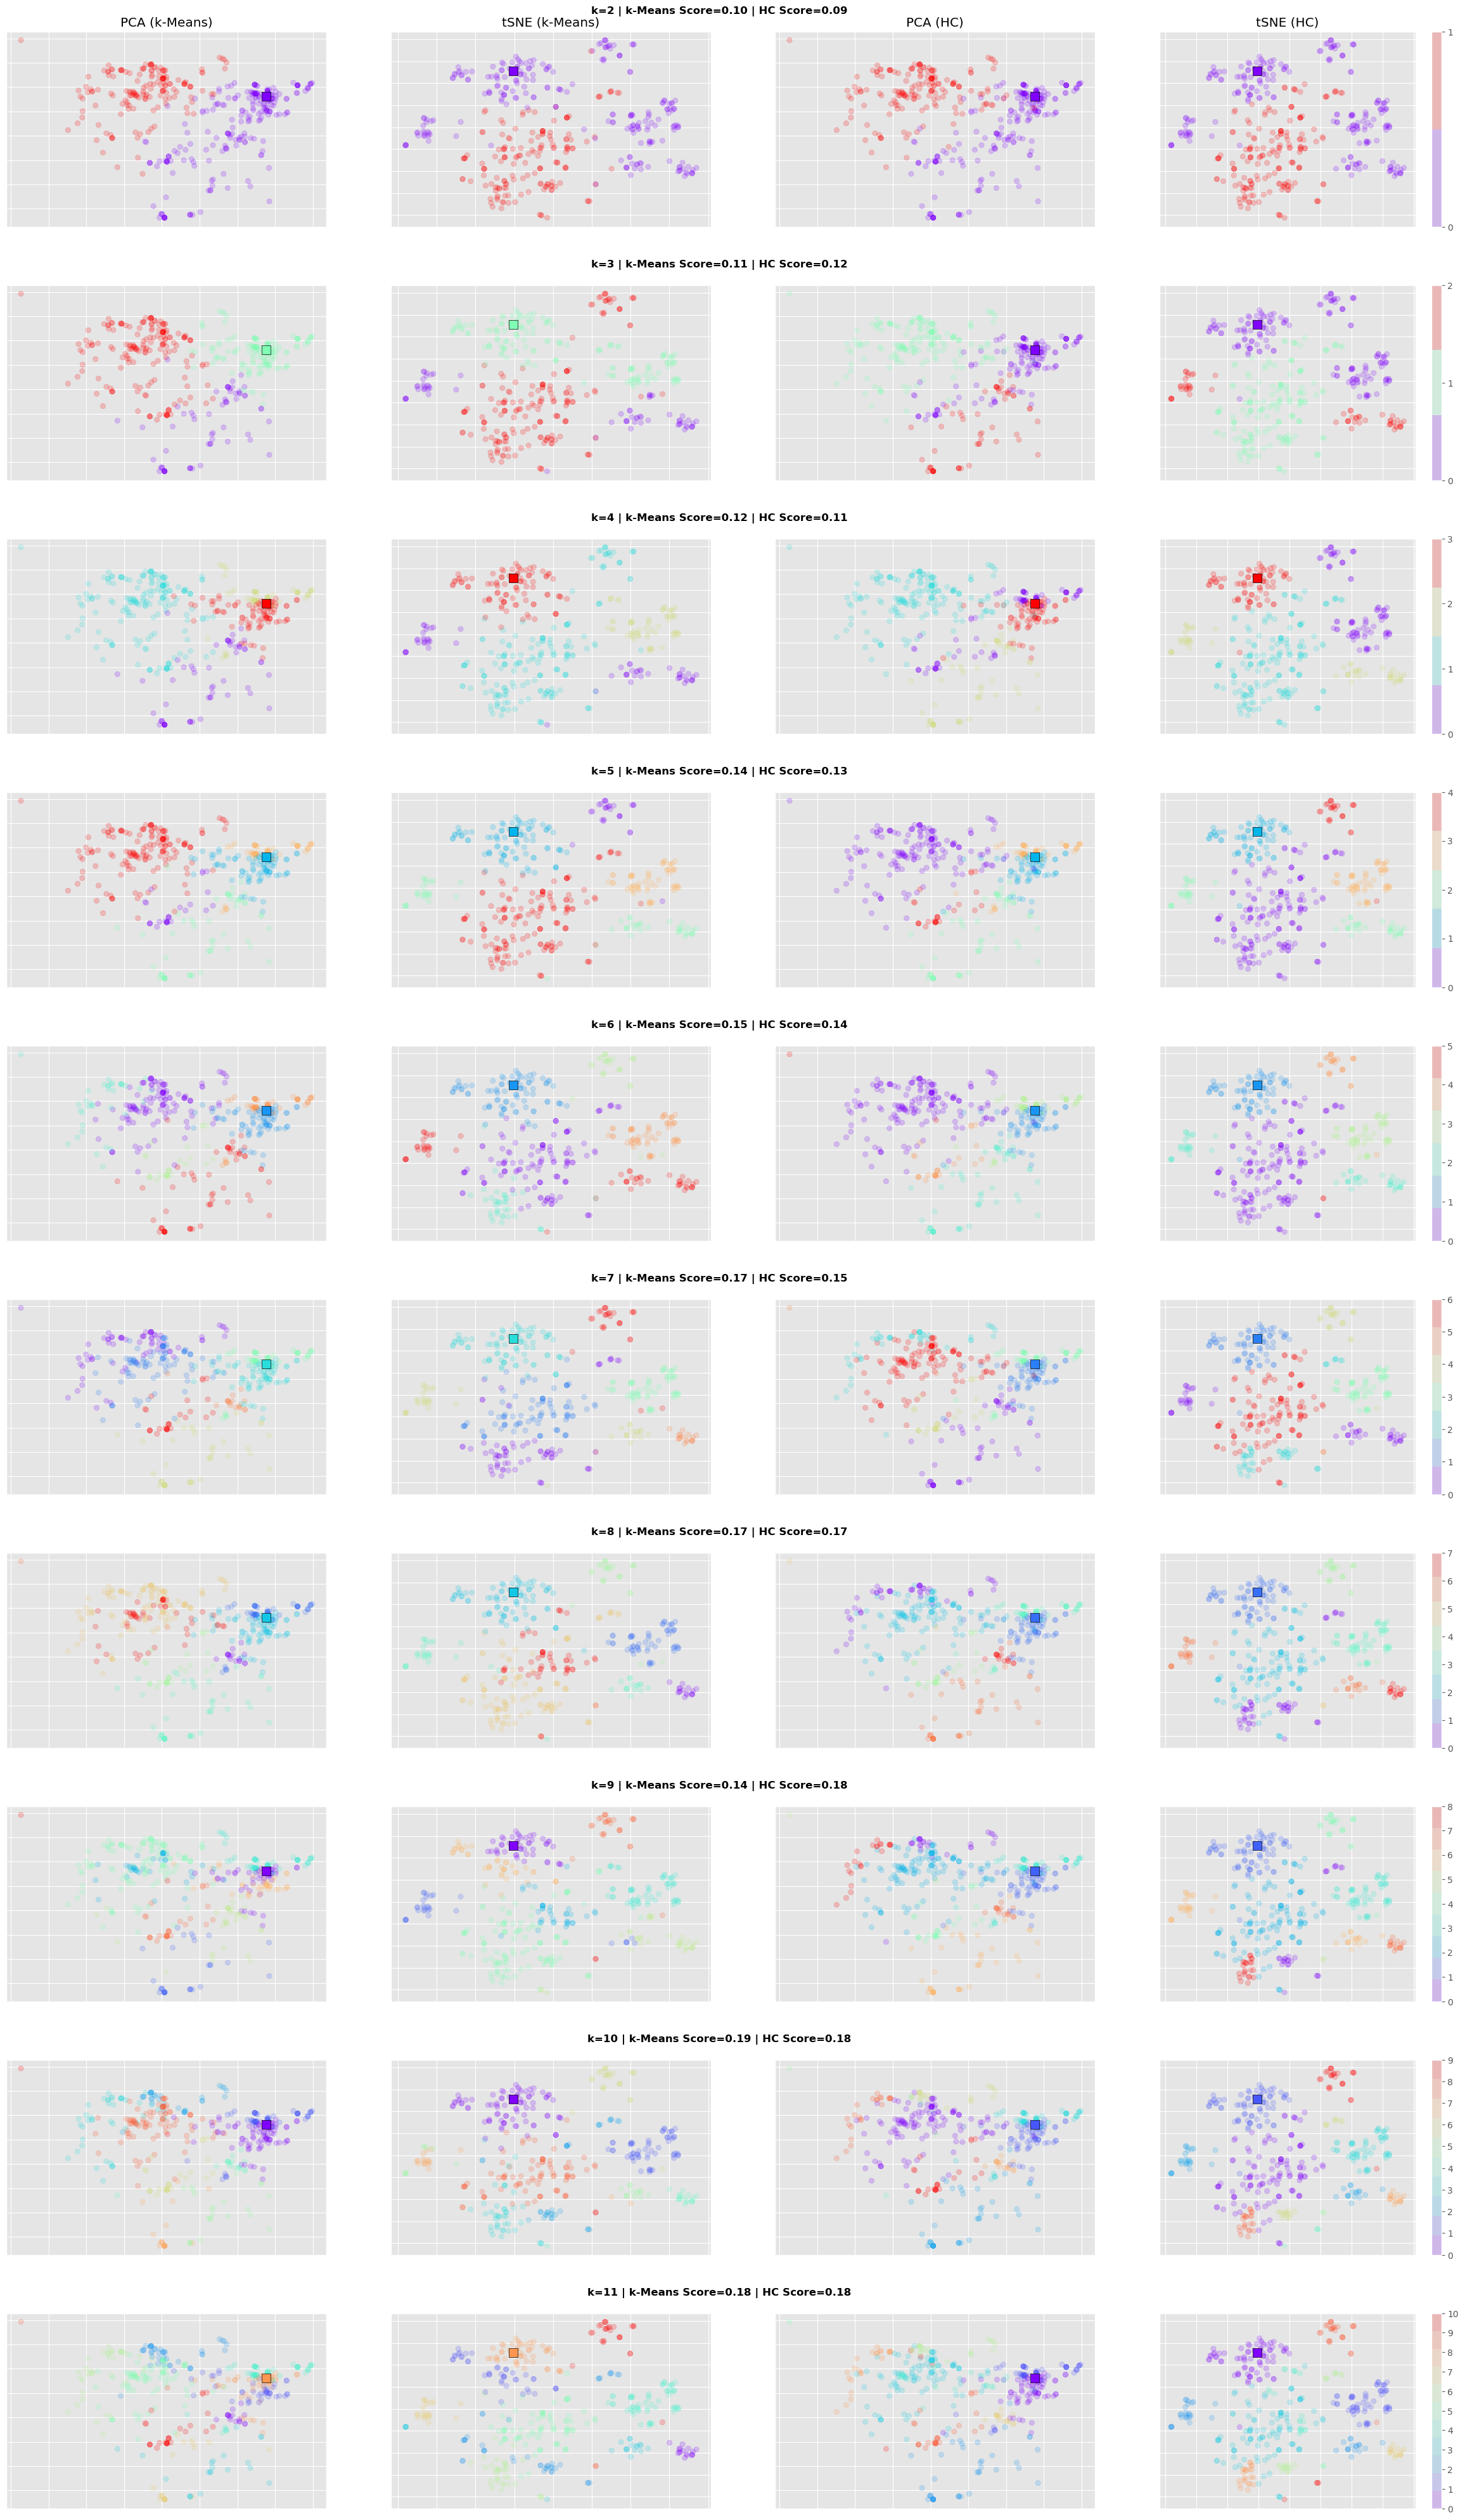

In [36]:
# and in all clusters
# plot hc and kmeans clusters side by side
# plot hc clusters with tsne / pca
# plot clusters with tsne
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(30, 40))

    # create subplots
    subfigs = fig.subfigures(len(fits), 1)

    for row, subfig in enumerate(subfigs):
        cmap = plt.get_cmap('rainbow', len(np.unique(fits[row].labels_)))
        # get kmeans classes
        kmeans_classes = fits[row].labels_
        kmeans_clist = {i: cmap(i) for i in range(len(np.unique(kmeans_classes)))}
        kmeans_score = scores[row]

        # get hc classes
        agg_classes = agg_fits[row]
        agg_clist = {i: cmap(i) for i in range(len(np.unique(agg_classes)))}
        agg_score = agg_scores[row]

        soi_kmeans_classes = [kmeans_classes[i] for i in soi_idx]
        soi_agg_classes = [agg_classes[i] for i in soi_idx]

        subfig.suptitle(f'k={row+2} | k-Means Score={kmeans_score:.2f} | HC Score={agg_score:.2f}', weight='bold')

        ax = subfig.subplots(nrows=1, ncols=4)

        # plot pca (all points)
        ax[0].scatter(pca_result[:,0], pca_result[:,1], c=kmeans_classes, cmap=cmap, alpha = 0.2)
        ax[0].scatter(rand_jitter(soi_pca[:,0]),rand_jitter(soi_pca[:,1]), marker=",", c=[kmeans_clist[i] for i in soi_kmeans_classes], edgecolor='black', s=100)

        ax[2].scatter(pca_result[:,0], pca_result[:,1], c=agg_classes, cmap=cmap, alpha = 0.2)
        ax[2].scatter(rand_jitter(soi_pca[:,0]),rand_jitter(soi_pca[:,1]), marker=",", c=[agg_clist[i] for i in soi_agg_classes], edgecolor='black', s=100)

        # plot tsne
        ax[1].scatter(tsne_results[:,0], tsne_results[:,1], c=kmeans_classes, cmap=cmap, alpha = 0.2)
        ax[1].scatter(rand_jitter(soi_tsne[:,0]),rand_jitter(soi_tsne[:,1]), marker=",", c=[kmeans_clist[i] for i in soi_kmeans_classes], edgecolor='black', s=100)
        subfig.colorbar(ax[3].scatter(tsne_results[:,0], tsne_results[:,1], c=agg_classes, cmap=cmap, alpha = 0.2),
                        ticks = range(0, row+2),  
                        format = '%1i')
        ax[3].scatter(rand_jitter(soi_tsne[:,0]),rand_jitter(soi_tsne[:,1]), marker=",", c=[agg_clist[i] for i in soi_agg_classes], edgecolor='black', s=100)

        if row == 0:
            ax[0].set_title('PCA (k-Means)')
            ax[1].set_title('tSNE (k-Means)')
            ax[2].set_title('PCA (HC)')
            ax[3].set_title('tSNE (HC)')

        for i in range(4):
            ax[i].tick_params(left = False, right = False , labelleft = False , 
                            labelbottom = False, bottom = False)
        
    plt.show()


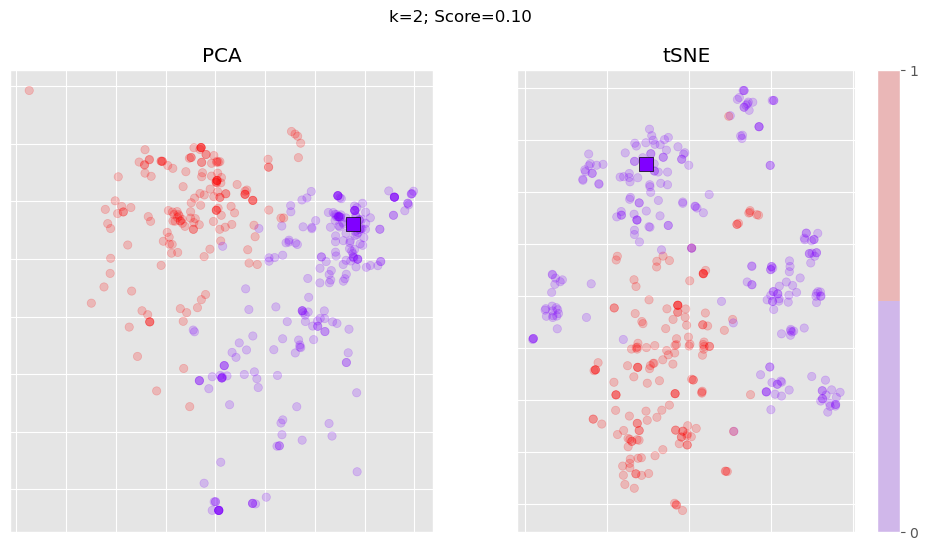

In [37]:
# plot at k=7 only
# plot clusters with tsne
k = best_kmeans_k
#k=6
with plt.style.context('ggplot'):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    row = k - 2 # subtract 2 to get proper index

    cmap = plt.get_cmap('rainbow', row+2)


    # get classes
    classes = fits[row].labels_

    # map classes to colors
    clist = {i:cmap(i) for i in range(row+2)} 

    score = scores[row]


    # get labels and index for each sequence of interest
    soi_classes = classes[soi_idx]

    # plot pca (all clusters)
    ax[0].scatter(pca_result[:,0], pca_result[:,1], c=classes, cmap=cmap, alpha=0.2)
    ax[0].scatter(rand_jitter(soi_pca[:,0]),rand_jitter(soi_pca[:,1]), marker=",", c=[clist[i] for i in soi_classes], edgecolor='black', s=100)

    # plot tsne
    plt.colorbar(ax[1].scatter(tsne_results[:,0], tsne_results[:,1], c=classes, cmap=cmap, alpha=0.2),
                    ticks = range(0, row+2),  
                    format = '%1i')

    ax[1].scatter(rand_jitter(soi_tsne[:,0]),rand_jitter(soi_tsne[:,1]), marker=",", c=[clist[i] for i in soi_classes], edgecolor='black', s=100)

    if row == 0:
        ax[0].set_title('PCA')
        ax[1].set_title('tSNE')

    ax[0].tick_params(left = False, right = False , labelleft = False , 
                        labelbottom = False, bottom = False)
    ax[1].tick_params(left = False, right = False , labelleft = False , 
                        labelbottom = False, bottom = False)

    plt.suptitle(f'k={row+2}; Score={score:.2f}')
    # Save plot as a file
    plt.savefig(f"../data/subcluster/subclustering_{cluster_number}_kmeans_pca_tsne_best_k.png", bbox_inches='tight')
    plt.show()


# Make Dataframe with Class Labels and Export

In [38]:
# Make a dataframe with the names, sequences, and cluster labels that are in best_kmeans
kmeans_labels = best_kmeans.labels_[seqs.index]

#kmeans_labels = chosen_kmeans.labels_[seqs.index]
agg_labels = best_agg[seqs.index]
sequence_id = seqs['sequence']


In [39]:
cluster_df = pd.DataFrame({'name': names, 'sequence': sequence_id, 'kmeans_label': kmeans_labels, 'agg_label': agg_labels})

In [40]:
cluster_df.head()

,name,sequence,kmeans_label,agg_label
0,ABD69154.1,EFWQEQERFEETGWDTGWDREQTCLCLCAILCAIHLFMQMQGPPYG...,0,0
1,ALT75848.1,EFWKEKERFAQTAWDTAWDREQTCLCLCALLCALHLFMQAEGPPYG...,0,0
2,CAA0125624.1,DYWHSHSHWVEIRFHIRFHQDRAAIAIVALIVALPTAAVYQKPPFK...,1,1
3,CAG1018993.1,SFWQQQQRFENVPWDVPWDREQTCLCLCALLCALHLFMQVEGPPYG...,1,1
4,HCY64078.1,DFWQTQTRFENTPWDTPWDREQTCLCLCALLCALHLFVQSKGPPYG...,1,1


In [41]:
# look at where sequences of interest are clustered
for name in names_in_data:
    print("Name:", name, "| Sequence:", cluster_df[cluster_df['name'] == name]["sequence"].values[0])
    print("K-Means Group:", cluster_df[cluster_df['name'] == name]["kmeans_label"].values[0], "")
    print()

Name: YP_522685.1_thiopurine_S-methyltransferase | Sequence: EFWQEQERFEETGWDTGWDREQTCLCLCAILCAIHLFMQMQGPPYGPPYHVSHP--NL--
K-Means Group: 0 

Name: YP_522685.1_thiopurine_S-methyltransferase | Sequence: EFWQEQERFEETGWDTGWDREQTCLCLCAILCAIHLFMQMQGPPYGPPYHVSHP--NL--
K-Means Group: 0 



In [42]:
cluster_df.to_csv(f"../data/subcluster/cluster_{cluster_number}_clustered_sequences_k{best_kmeans_k}.csv", index=False)